/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9246 - loss: 0.2635
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9668 - loss: 0.1135
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9771 - loss: 0.0773
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9823 - loss: 0.0578
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9861 - loss: 0.0443
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9745 - loss: 0.0805
Test Accuracy:0.9745
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


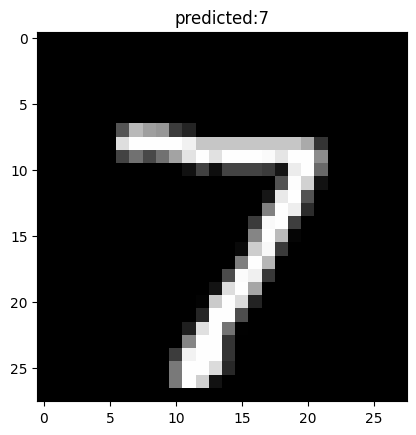

In [11]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt

# mnist = keras.datasets.mnist+ata()
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

x_train,x_test=x_train/255.0,x_test/255.0

model =keras.Sequential([
    keras.layers.Flatten(input_shape=(28,28)),
    keras.layers.Dense(128,activation='relu'),
    keras.layers.Dense(10,activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.fit(x_train,y_train,epochs=5)
test_loss,test_acc=model.evaluate(x_test,y_test)
print(f"Test Accuracy:{test_acc:.4f}")

predictions=model.predict(x_test)

plt.imshow(x_test[0],cmap='gray')
plt.title(f"predicted:{predictions[0].argmax()}")
plt.show()



/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 64s 34ms/step - accuracy: 0.9613 - loss: 0.1255 - val_accuracy: 0.9886 - val_loss: 0.0347
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 62s 33ms/step - accuracy: 0.9873 - loss: 0.0412 - val_accuracy: 0.9894 - val_loss: 0.0305
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 64s 34ms/step - accuracy: 0.9908 - loss: 0.0284 - val_accuracy: 0.9916 - val_loss: 0.0297
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 79s 32ms/step - accuracy: 0.9934 - loss: 0.0207 - val_accuracy: 0.9913 - val_loss: 0.0259
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 62s 33ms/step - accuracy: 0.9950 - loss: 0.0148 - val_accuracy: 0.9922 - val_loss: 0.0252
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9922 - loss: 0.0252
Test Accuracy: 0.9922
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step


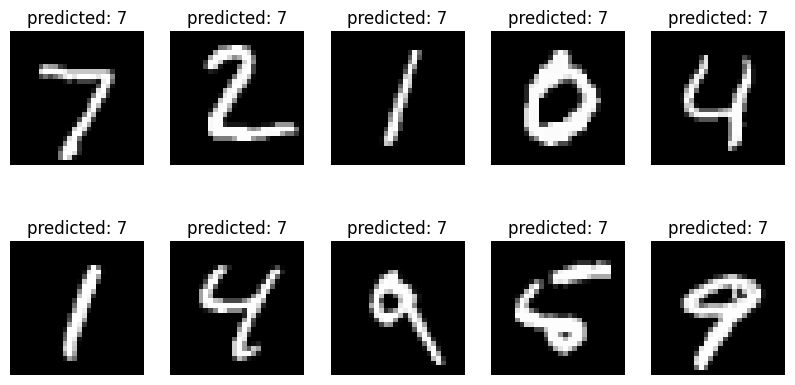

In [22]:

import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
from tensorflow.keras import layers

# Load and preprocess data
mnist=keras.datasets.mnist
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0

x_train = x_train.reshape(-1,28,28,1)
x_test = x_test.reshape(-1,28,28,1)

# Define the model
model = keras.Sequential([
    layers.Conv2D(32,(3,3),activation='relu',input_shape=(28,28,1)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64,(3,3),activation='relu'),
    layers.MaxPooling2D((2,2)),


    layers.Flatten(),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(10, activation='softmax')
])

# FIX: Changed 'ptimizer' to 'optimizer'
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Train and evaluate
model.fit(x_train, y_train, epochs=5,validation_data=(x_test,y_test))
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f"Test Accuracy: {test_acc:.4f}")

# Predict and plot
predictions = model.predict(x_test)


plt.figure(figsize=(10,5))
for i in range(10):
  plt.subplot(2,5,i+1)
  plt.imshow(x_test[i].reshape(28,28), cmap='gray')
  plt.title(f"predicted: {predictions[0].argmax()}")
  plt.axis('off')
plt.show()
